In [4]:
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np

from pathlib import Path
import soundfile as sf

In [5]:
def plot_audio_seg_spectrogram(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=(15, 5))
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Spectrogram", fontsize=24)
    plt.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
            labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.colorbar()
    plt.show()

In [9]:
HARD_DRIVE_LOC = Path('/Volumes')

In [10]:
experiment_folder = HARD_DRIVE_LOC
experiment_folder

PosixPath('/Volumes')

In [14]:
all_wav_files = list(experiment_folder.glob('STF_*/2026*.WAV'))
all_wav_files

[PosixPath('/Volumes/STF_063/20260527_000358.WAV'),
 PosixPath('/Volumes/STF_063/20260528_182406.WAV'),
 PosixPath('/Volumes/STF_063/20260528_203702.WAV'),
 PosixPath('/Volumes/STF_064/20260526_235528.WAV'),
 PosixPath('/Volumes/STF_064/20260527_000016.WAV'),
 PosixPath('/Volumes/STF_064/20260528_182428.WAV'),
 PosixPath('/Volumes/STF_064/20260528_204111.WAV')]

In [15]:
valid_wav_files = []
for wav_file in all_wav_files:
    wave_file_dt = dt.datetime.strptime(wav_file.name, '%Y%m%d_%H%M%S.WAV')
    if wave_file_dt >= dt.datetime(2026, 5, 28, 20, 35, 0):
        valid_wav_files += [wav_file]
valid_wav_files

[PosixPath('/Volumes/STF_063/20260528_203702.WAV'),
 PosixPath('/Volumes/STF_064/20260528_204111.WAV')]

In [16]:
SD_CARD_TO_AUDIOMOTH_NUM = {'STF_021': '016', 'STF_005': '027', 'STF_027': '020', 'STF_114': '040', 'STF_002': '034'}
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_021': '016',
 'STF_005': '027',
 'STF_027': '020',
 'STF_114': '040',
 'STF_002': '034'}

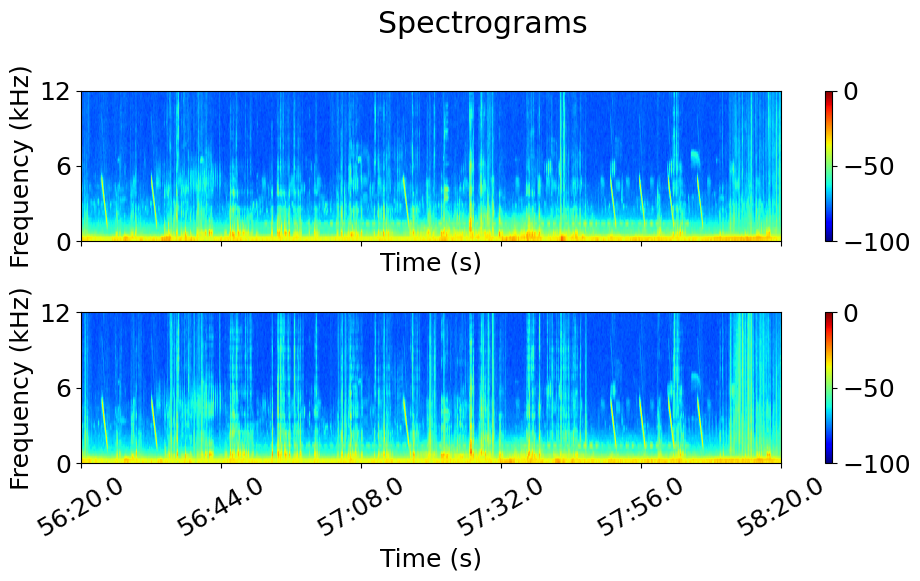

In [20]:
recording_start_dt = dt.datetime(2026, 5, 28, 20, 56, 20)
SAMPLERATE = 192000

fig, ax_all = plt.subplots(len(valid_wav_files), 1, figsize=(10, 6), sharex = True)
plt.rcParams.update({'font.size': 18})
fig.suptitle(f'Spectrograms')

for i, example_wav_file in enumerate(valid_wav_files):
    ax = ax_all[i]

    example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
    samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
    recorded_audio = sf.SoundFile(example_wav_file)
    read_offset = samples_until_recording_start
    read_duration_in_secs = 120
    recorded_audio.seek(int(SAMPLERATE*read_offset))
    audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))

    vmax = 0
    vmin = -100

    audio_features = dict()
    audio_features['audio_seg'] = audio_seg
    audio_features['sample_rate'] = SAMPLERATE
    audio_features['start'] = read_offset
    audio_features['duration'] = read_duration_in_secs

    spec_features = dict()
    spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
    spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
    spec_features['vmin'] = vmin
    spec_features['vmax'] = vmax

    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    spec, freqs, t, im = ax.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    ax.set_yticks(ticks=np.linspace(0, 1/8, 3), labels=np.linspace(0, 1/8 * (fs/2000), 3).astype('int'))
    ax.set_ylim(0, 1/8)
    times = []
    for s in np.linspace(0, duration, 6):
        times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%M:%S.%f"))[:7]]
    ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 6), labels=times, rotation=30)
    fig.colorbar(im, ax=ax)
    ax.set_ylabel("Frequency (kHz)")
    ax.set_xlabel("Time (s)") 
fig.tight_layout()
plt.show()

In [22]:
recording_start_dt = dt.datetime(2026, 5, 28, 20, 57, 50)
SAMPLERATE = 192000

example_wav_file = valid_wav_files[-1]

example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
recorded_audio = sf.SoundFile(example_wav_file)
read_offset = samples_until_recording_start
read_duration_in_secs = 18
recorded_audio.seek(int(SAMPLERATE*read_offset))
audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))

In [23]:
import scipy.signal as sig
from IPython.display import Audio

listen_rate = 48000
audio_listen = sig.resample_poly(audio_seg, listen_rate, SAMPLERATE)

Audio(audio_listen, rate=listen_rate)